In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Function 1: Classify Lane Changes
def classify_lane_changes(tracks_df):
    tracks_df['laneChangeType'] = 0
    def lane_change_logic(df):
        lane_diff = df['laneId'].diff()
        direction = df['drivingDirection'].iloc[0]
        lane_change = np.where(
            (lane_diff > 0) & (direction == 1), 1,
            np.where((lane_diff < 0) & (direction == 1), -1,
                     np.where((lane_diff > 0) & (direction == 2), -1,
                              np.where((lane_diff < 0) & (direction == 2), 1, 0)))
        )
        return lane_change
    tracks_df['laneChangeType'] = tracks_df.groupby('id', group_keys=False).apply(lane_change_logic)
    return tracks_df

# Function 2: Calculate Acceleration
def calculate_acceleration(tracks_df):
    tracks_df['xAcceleration'] = tracks_df.groupby('id')['xVelocity'].diff().fillna(0)
    tracks_df['yAcceleration'] = tracks_df.groupby('id')['yVelocity'].diff().fillna(0)
    return tracks_df

# Function 3: Calculate Relative Positions and Velocities
def calculate_relative_positions_and_velocities(tracks_df):
    def calculate_relative_data(row):
        surrounding_ids = [
            row['precedingId'], row['followingId'],
            row['leftPrecedingId'], row['leftAlongsideId'], row['leftFollowingId'],
            row['rightPrecedingId'], row['rightAlongsideId'], row['rightFollowingId']
        ]
        surrounding_data = {}
        for i, s_id in enumerate(surrounding_ids):
            if s_id > 0:
                s_vehicle = tracks_df[tracks_df['id'] == s_id]
                if not s_vehicle.empty:
                    dx = s_vehicle['x'].values[0] - row['x']
                    dy = s_vehicle['y'].values[0] - row['y']
                    dvx = s_vehicle['xVelocity'].values[0] - row['xVelocity']
                    dvy = s_vehicle['yVelocity'].values[0] - row['yVelocity']
                    surrounding_data[f'vehicle_{i+1}_relative_x'] = dx
                    surrounding_data[f'vehicle_{i+1}_relative_y'] = dy
                    surrounding_data[f'vehicle_{i+1}_relative_vx'] = dvx
                    surrounding_data[f'vehicle_{i+1}_relative_vy'] = dvy
                else:
                    surrounding_data[f'vehicle_{i+1}_relative_x'] = np.nan
                    surrounding_data[f'vehicle_{i+1}_relative_y'] = np.nan
                    surrounding_data[f'vehicle_{i+1}_relative_vx'] = np.nan
                    surrounding_data[f'vehicle_{i+1}_relative_vy'] = np.nan
            else:
                surrounding_data[f'vehicle_{i+1}_relative_x'] = np.nan
                surrounding_data[f'vehicle_{i+1}_relative_y'] = np.nan
                surrounding_data[f'vehicle_{i+1}_relative_vx'] = np.nan
                surrounding_data[f'vehicle_{i+1}_relative_vy'] = np.nan
        return surrounding_data
    relative_data = tracks_df.apply(calculate_relative_data, axis=1)
    relative_data_df = pd.DataFrame(relative_data.tolist())
    tracks_df = pd.concat([tracks_df, relative_data_df], axis=1)
    return tracks_df

# Function 4: Fill Missing Values
def fill_missing_values(df):
    # Identify columns based on the column naming pattern
    relative_position_columns = [col for col in df.columns if 'relative_x' in col or 'relative_y' in col]
    velocity_columns = [col for col in df.columns if 'relative_vx' in col or 'relative_vy' in col]

    # Use xVelocity and yVelocity as references for ego vehicle velocity
    ego_vx = df['xVelocity']  # Ego vehicle's x velocity
    ego_vy = df['yVelocity']  # Ego vehicle's y velocity

    # Replace blanks in position columns with -1
    for col in relative_position_columns:
        df[col] = df[col].fillna(-1)

    # Replace blanks in velocity columns with ego vehicle's velocity
    for col in velocity_columns:
        if 'relative_vx' in col:
            df[col] = df[col].fillna(ego_vx)
        elif 'relative_vy' in col:
            df[col] = df[col].fillna(ego_vy)

    return df

# Function 5: Normalize Selected Columns
def normalize_selected_columns(df):
    exclude_columns = [
        'frame', 'id', 'drivingDirection', 'initialFrame', 'finalFrame',
        'numFrames', 'precedingId', 'followingId', 'leftPrecedingId',
        'leftAlongsideId', 'leftFollowingId', 'rightPrecedingId',
        'rightAlongsideId', 'rightFollowingId', 'laneId'
    ]
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    columns_to_normalize = [col for col in numerical_columns if col not in exclude_columns]

    scaler = StandardScaler()
    df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
    return df

# Main Execution
if __name__ == "__main__":
    # Load the meta and track data
    tracks_df = pd.read_csv('01_tracks.csv')
    meta_df = pd.read_csv('01_tracksMeta.csv')

    # Merge meta features with tracks
    combined_df = tracks_df.merge(meta_df, on='id', how='left')

    # Classify lane changes
    combined_df = classify_lane_changes(combined_df)

    # Calculate acceleration
    combined_df = calculate_acceleration(combined_df)

    # Calculate relative positions and velocities
    combined_df = calculate_relative_positions_and_velocities(combined_df)

    # Fill missing values
    combined_df = fill_missing_values(combined_df)

    # Normalize selected numerical columns
    combined_df = normalize_selected_columns(combined_df)

    # Save the final processed data
    combined_df.to_csv('processed_traffic_data.csv', index=False)

    print("Data preprocessing complete. File saved as 'processed_traffic_data.csv'.")



<ipython-input-2-d65877e409e8>:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracks_df['laneChangeType'] = tracks_df.groupby('id', group_keys=False).apply(lane_change_logic)


Data preprocessing complete. File saved as 'processed_traffic_data.csv'.


# View the Output
**The code will generate a 2D trajectory plot with:**

**Lane Differentiation:** Different markers for different lanes.

**Velocity Mapping:** Points above the speed limit are highlighted in red; others are blue.
The plot will automatically display in the Colab notebook.

<ipython-input-3-42febea2509a>:7: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_df = pd.read_csv(file_path)


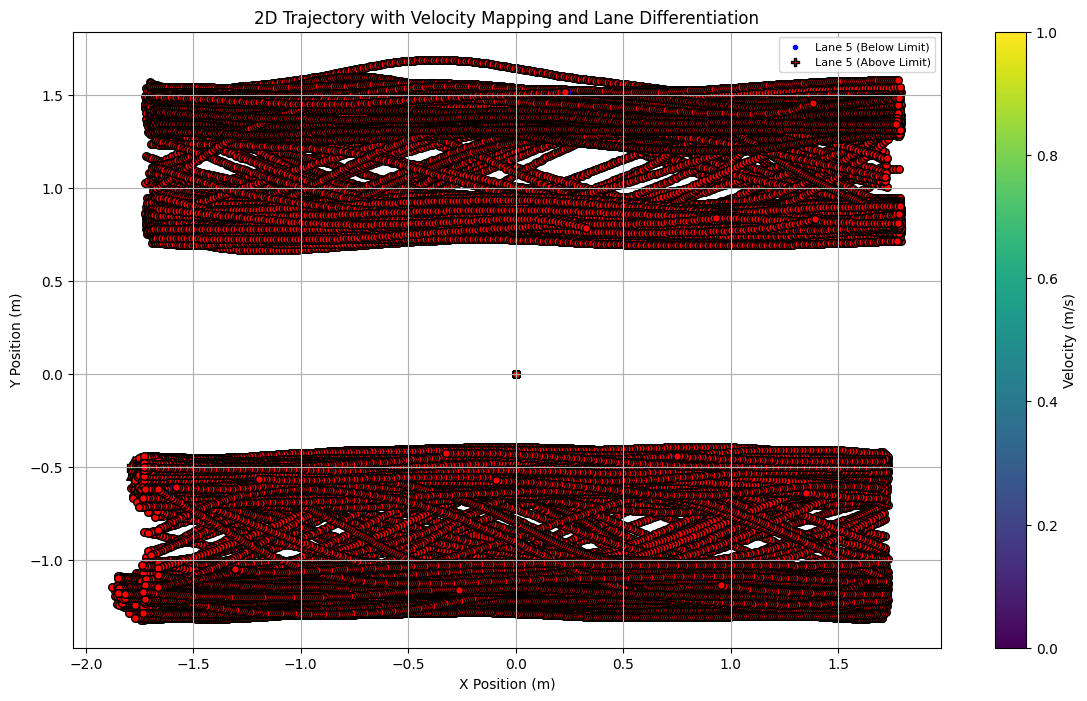

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from 'traffic_scenario_data_combined.csv'
file_path = '/content/processed_traffic_data.csv'
combined_df = pd.read_csv(file_path)

# Simulated Data (adapted for the dataset)
num_vehicles = combined_df['id'].nunique()  # Unique vehicles
num_frames = combined_df['frame'].max()  # Total frames
x_positions = combined_df.pivot(index='frame', columns='id', values='x').fillna(0).values.T  # X positions
y_positions = combined_df.pivot(index='frame', columns='id', values='y').fillna(0).values.T  # Y positions
lane_ids = combined_df.pivot(index='frame', columns='id', values='laneId').fillna(0).values.T  # Lane IDs
timestamps = np.linspace(0, 3, num_frames)  # Simulated time (seconds)

# Define lane speed limits
def get_speed_limit(lane_id):
    if lane_id in (1, 4):
        return 70  # km/h
    elif lane_id in (2, 5):
        return 90  # km/h
    elif lane_id in (3, 6):
        return 120  # km/h
    else:
        return 0

# Convert speed limit to m/s
velocity_limits = np.array([[get_speed_limit(lane) * 1000 / 3600 for lane in row] for row in lane_ids])

# Calculate velocities
velocities = np.sqrt(np.diff(x_positions, axis=1)**2 + np.diff(y_positions, axis=1)**2) / np.diff(timestamps)

# Add last frame with zeros to match the shape
velocities = np.hstack([velocities, np.zeros((num_vehicles, 1))])

# Define shapes for different lanes
lane_shapes = {
    1: 'o', 2: 's', 3: '^', 4: 'D', 5: 'P', 6: 'X'
}

# Create a 2D trajectory plot
plt.figure(figsize=(14, 8))
for i in range(num_vehicles):
    # Get the lane and marker for this vehicle
    lane_id = int(lane_ids[i, 0])  # Assume first frame lane as representative
    marker = lane_shapes.get(lane_id, 'o')  # Default to circle if lane not found

    # Highlight points exceeding speed limit in red
    above_limit = velocities[i] > velocity_limits[i]
    below_limit = ~above_limit

    # Plot points below speed limit
    plt.scatter(x_positions[i, below_limit], y_positions[i, below_limit],
                c='blue', s=10, label=f'Lane {lane_id} (Below Limit)' if i == 0 else "", marker=marker)

    # Plot points above speed limit with more intensity
    plt.scatter(x_positions[i, above_limit], y_positions[i, above_limit],
                c='red', edgecolor='black', s=30, label=f'Lane {lane_id} (Above Limit)' if i == 0 else "", marker=marker)

# Add a color bar for velocity
cbar = plt.colorbar()
cbar.set_label('Velocity (m/s)')

# Add labels and legend
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('2D Trajectory with Velocity Mapping and Lane Differentiation')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)

plt.show()
